# Finding rate RNN fixed points

- plotting for multiple models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys
import pickle as pk
from sklearn.decomposition import PCA

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

2025-03-02 15:36:20.592918: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-02 15:36:20.602212: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-02 15:36:20.611244: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-02 15:36:20.613993: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-02 15:36:20.621624: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


## Good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
good_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.60e-02 +/- 2.42e-03, dq = 1.16e-04 +/- 1.79e-05, learning rate = 1.00e-01, avg iter time = 1.07e-03 sec.
	Iter: 200, q = 8.68e-03 +/- 1.67e-03, dq = 5.17e-05 +/- 8.97e-06, learning rate = 1.00e-01, avg iter time = 9.92e-04 sec.
	Iter: 300, q = 4.70e-03 +/- 1.10e-03, dq = 3.54e-05 +/- 3.50e-05, learning rate = 1.00e-01, avg iter time = 9.61e-04 sec.
	Iter: 400, q = 2.48e-03 +/- 6.75e-04, dq = 3.74e-05 +/- 6.83e-05, learning rate = 1.00e-01, avg iter time = 9.51e-04 sec.
	Iter: 500, q = 1.32e-03 +/- 3.67e-04, dq = 1.22e-05 +/- 2.59e

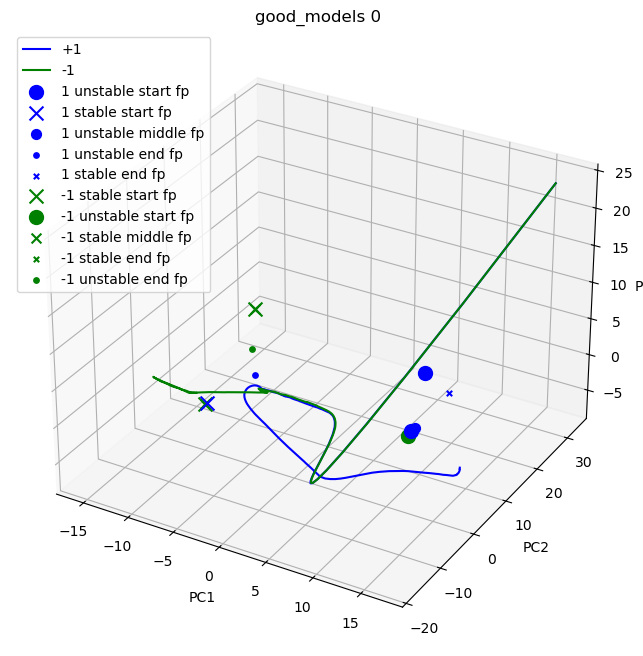

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160424.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160424.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.15e-02 +/- 1.61e-03, dq = 1.32e-04 +/- 2.29e-05, learning rate = 1.00e-01, avg iter time = 9.53e-04 sec.
	Iter: 200, q = 4.66e-03 +/- 8.89e-04, dq = 3.57e-05 +/- 5.52e-06, learning rate = 1.00e-01, avg iter time = 9.35e-04 sec.
	Iter: 300, q = 2.34e-03 +/- 5.77e-04, dq = 1.61e-05 +/- 1.30e-05, learning rate = 1.00e-01, avg iter time = 9.29e-04 sec.
	Iter: 400, q = 1.24e-03 +/- 3.75e-04, dq = 9.86e-06 +/- 1.55e-05, learning rate = 1.00e-01, avg iter time = 9.24e-04 sec.
	Iter: 500, q = 6.74e-04 +/- 3.14e-04, dq = 8.88e-06 +/- 3.84e

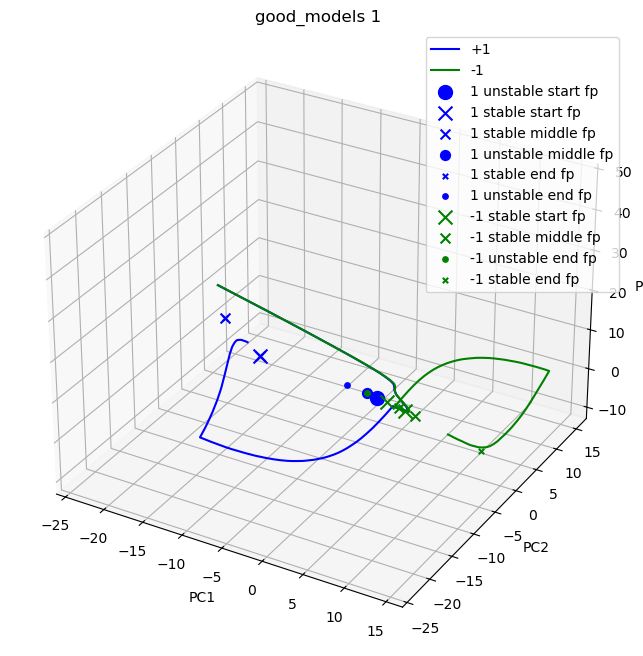

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_162018.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_162018.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.11e-02 +/- 1.45e-03, dq = 1.17e-04 +/- 1.25e-05, learning rate = 1.00e-01, avg iter time = 9.33e-04 sec.
	Iter: 200, q = 4.81e-03 +/- 8.17e-04, dq = 6.55e-05 +/- 1.27e-04, learning rate = 1.00e-01, avg iter time = 9.23e-04 sec.
	Iter: 300, q = 2.40e-03 +/- 4.81e-04, dq = 4.82e-05 +/- 1.27e-04, learning rate = 9.50e-02, avg iter time = 9.24e-04 sec.
	Iter: 400, q = 1.26e-03 +/- 2.98e-04, dq = 4.81e-05 +/- 1.43e-04, learning rate = 8.57e-02, avg iter time = 9.23e-04 sec.
	Iter: 500, q = 7.28e-04 +/- 1.97e-04, dq = 3.81e-06 +/- 2.17e

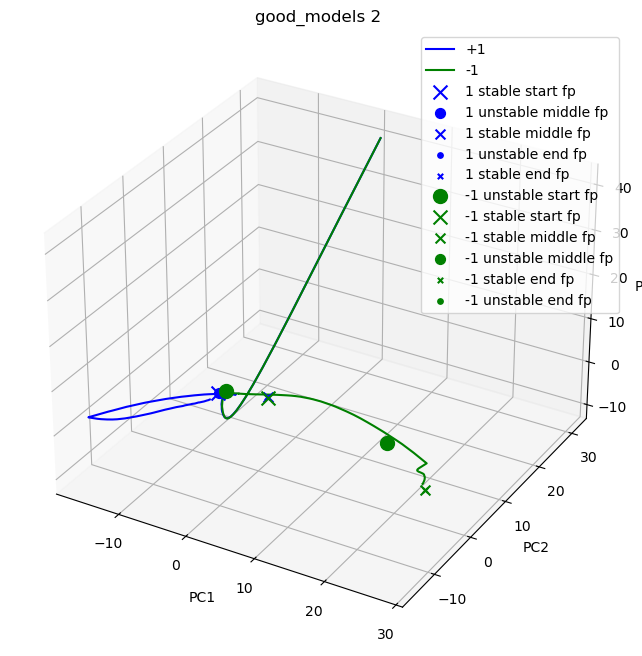

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163956.mat
Generating synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163956.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 4.31e-03 +/- 8.45e-04, dq = 5.47e-05 +/- 1.02e-05, learning rate = 1.00e-01, avg iter time = 9.54e-04 sec.
	Iter: 200, q = 1.68e-03 +/- 3.64e-04, dq = 1.52e-05 +/- 1.46e-05, learning rate = 1.00e-01, avg iter time = 1.04e-03 sec.
	Iter: 300, q = 8.65e-04 +/- 2.01e-04, dq = 2.22e-05 +/- 5.98e-05, learning rate = 1.00e-01, avg iter time = 1.07e-03 sec.
	Iter: 400, q = 5.13e-04 +/- 1.27e-04, dq = 6.35e-06 +/- 1.72e-05, learning rate = 9.02e-02, avg iter time = 1.08e-03 sec.
	Iter: 500, q = 3.48e-04 +/- 8.93e-05, dq = 1.28e-06 +/- 1.

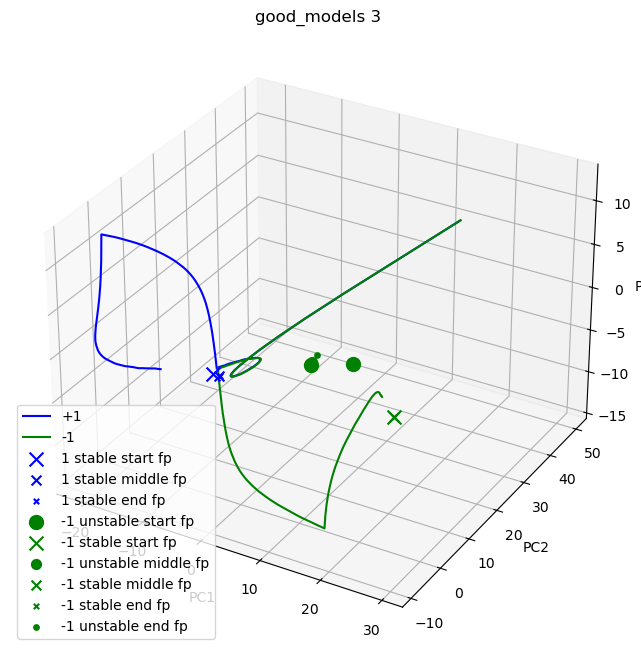

In [4]:
importlib.reload(tu)
for i_model, RNN_model_file in enumerate(good_model_list):
    model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

    print(f'Loading model: {RNN_model_file}')
    rnn_path = os.path.join(models_dir, RNN_model_file) 
    model = lrm.load_RNN_model(rnn_path)

    # get xx_trials
    if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
            print('Generating synX')
            xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                    save=1, model_results_dir = model_results_dir)
    else:
            print('Loading synX')
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

    # get fixed points
    if os.path.exists(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl'):
        print('loading fixed point optimization results')
        fixed_pt_results = pk.load(open(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl', 'rb'))
    else:
        print('Running fixed point optimization')

        _ = tu.calculate_fixed_pts(RNN_model_file = RNN_model_file, xx_trials = xx_trials,
                                                trial_stim_labels = trial_stim_labels, settings = settings,
                                                save=1, models_dir = models_dir)
        fixed_pt_results = pk.load(open(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl', 'rb'))

    # now PCA and plot
    tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0,
                   title=f'{models_type} {i_model}')
    
    if i_model == 3:
          break


## Bad model

In [5]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

In [6]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
bad_model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.79e-02 +/- 2.41e-03, dq = 1.67e-04 +/- 2.36e-05, learning rate = 1.00e-01, avg iter time = 9.96e-04 sec.
	Iter: 200, q = 9.47e-03 +/- 1.55e-03, dq = 5.16e-05 +/- 2.95e-05, learning rate = 1.00e-01, avg iter time = 9.89e-04 sec.
	Iter: 300, q = 5.97e-03 +/- 1.14e-03, dq = 9.83e-05 +/- 2.14e-04, learning rate = 1.00e-01, avg iter time = 9.92e-04 sec.
	Iter: 400, q = 3.84e-03 +/- 8.81e-04, dq = 6.94e-05 +/- 1.96e-04, learning rate = 9.50e-02, avg iter time = 9.90e-04 sec.
	Iter: 500, q = 2.51e-03 +/- 5.68e-04, dq = 2.25e-05 +/- 7.09e

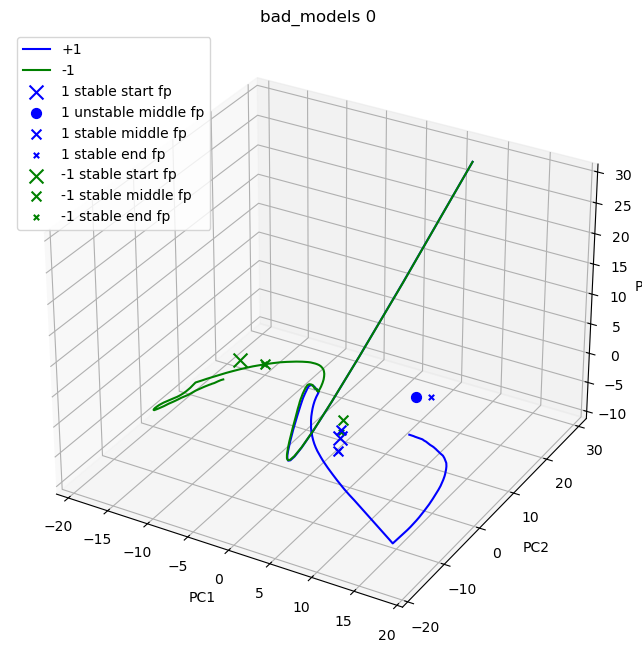

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.88e-02 +/- 3.60e-03, dq = 1.62e-04 +/- 3.49e-05, learning rate = 1.00e-01, avg iter time = 9.40e-04 sec.
	Iter: 200, q = 1.06e-02 +/- 2.18e-03, dq = 5.35e-05 +/- 1.08e-05, learning rate = 1.00e-01, avg iter time = 9.30e-04 sec.
	Iter: 300, q = 6.29e-03 +/- 1.46e-03, dq = 4.74e-05 +/- 8.97e-05, learning rate = 1.00e-01, avg iter time = 9.28e-04 sec.
	Iter: 400, q = 3.66e-03 +/- 8.59e-04, dq = 5.23e-05 +/- 1.27e-04, learning rate = 1.00e-01, avg iter time = 9.29e-04 sec.
	Iter: 500, q = 2.16e-03 +/- 5.26e-04, dq = 2.50e-05 +/- 7.77e

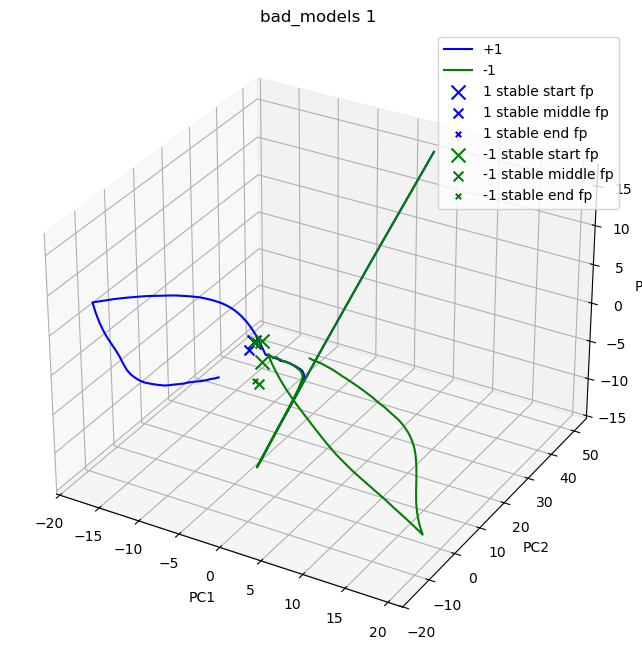

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_171227.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_171227.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.02e-02 +/- 1.93e-03, dq = 1.52e-04 +/- 2.46e-05, learning rate = 1.00e-01, avg iter time = 9.33e-04 sec.
	Iter: 200, q = 2.96e-03 +/- 7.70e-04, dq = 3.06e-05 +/- 7.13e-06, learning rate = 1.00e-01, avg iter time = 9.28e-04 sec.
	Iter: 300, q = 1.26e-03 +/- 4.29e-04, dq = 8.88e-06 +/- 2.59e-06, learning rate = 1.00e-01, avg iter time = 9.29e-04 sec.
	Iter: 400, q = 7.03e-04 +/- 2.90e-04, dq = 3.94e-06 +/- 4.94e-06, learning rate = 1.00e-01, avg iter time = 9.26e-04 sec.
	Iter: 500, q = 4.64e-04 +/- 2.11e-04, dq = 1.62e-06 +/- 7.59e

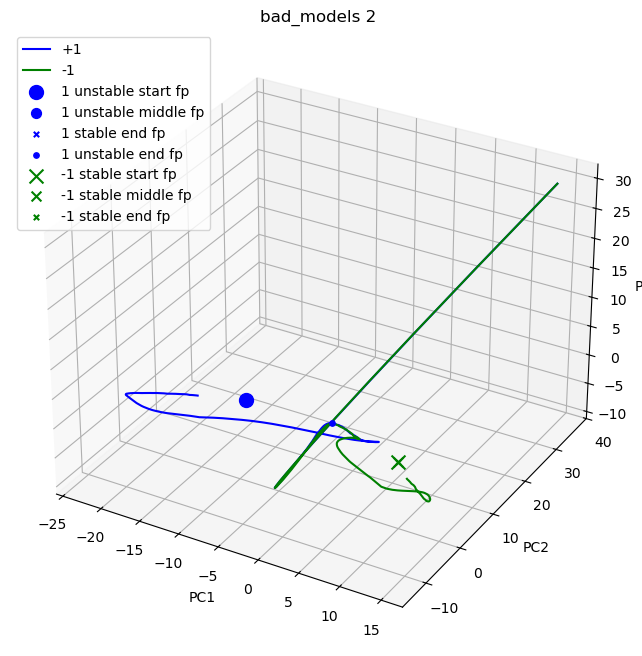

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_171933.mat
Loading synX
Running fixed point optimization
Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_171933.mat
Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.31e-02 +/- 1.55e-03, dq = 9.75e-05 +/- 1.48e-05, learning rate = 1.00e-01, avg iter time = 8.36e-04 sec.
	Iter: 200, q = 7.54e-03 +/- 1.03e-03, dq = 3.54e-05 +/- 4.51e-06, learning rate = 1.00e-01, avg iter time = 8.27e-04 sec.
	Iter: 300, q = 4.95e-03 +/- 7.49e-04, dq = 3.21e-05 +/- 8.81e-05, learning rate = 1.00e-01, avg iter time = 8.26e-04 sec.
	Iter: 400, q = 3.45e-03 +/- 5.47e-04, dq = 2.62e-05 +/- 8.13e-05, learning rate = 9.50e-02, avg iter time = 8.31e-04 sec.
	Iter: 500, q = 2.54e-03 +/- 4.29e-04, dq = 1.47e-05 +/- 4.40e

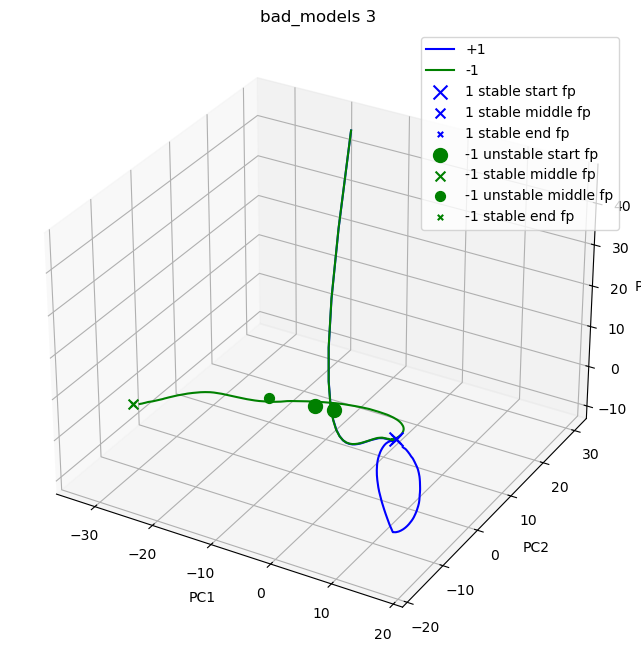

In [7]:
importlib.reload(tu)

for i_model, RNN_model_file in enumerate(bad_model_list):
    model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

    print(f'Loading model: {RNN_model_file}')
    rnn_path = os.path.join(models_dir, RNN_model_file) 
    model = lrm.load_RNN_model(rnn_path)

    # get xx_trials
    if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
            print('Generating synX')
            xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                    save=1, model_results_dir = model_results_dir)
    else:
            print('Loading synX')
            xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
            trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

    # get fixed points
    if os.path.exists(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl'):
        print('loading fixed point optimization results')
        fixed_pt_results = pk.load(open(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl', 'rb'))
    else:
        print('Running fixed point optimization')

        _ = tu.calculate_fixed_pts(RNN_model_file = RNN_model_file, xx_trials = xx_trials,
                                                trial_stim_labels = trial_stim_labels, settings = settings,
                                                save=1, models_dir = models_dir)
        fixed_pt_results = pk.load(open(f'{model_results_dir}delay{settings["delay"]}_fixed_pt_results.pkl', 'rb'))

    # now PCA and plot
    tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0,
                   title=f'{models_type} {i_model}')
    
    if i_model == 3:
          break
